<a href="https://colab.research.google.com/github/Kabaaaan/Simulation_modeling/blob/main/IM_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

https://docs.exponenta.ru/R2019a/robotics/ug/particle-filter-workflow.html

https://habr.com/ru/articles/276801/

https://kappa.cs.petrsu.ru/~lukashen/IM/

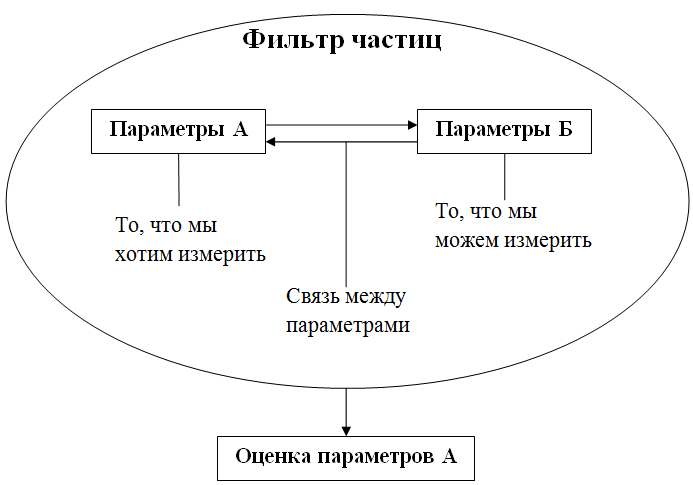

**Ресэмплинг**

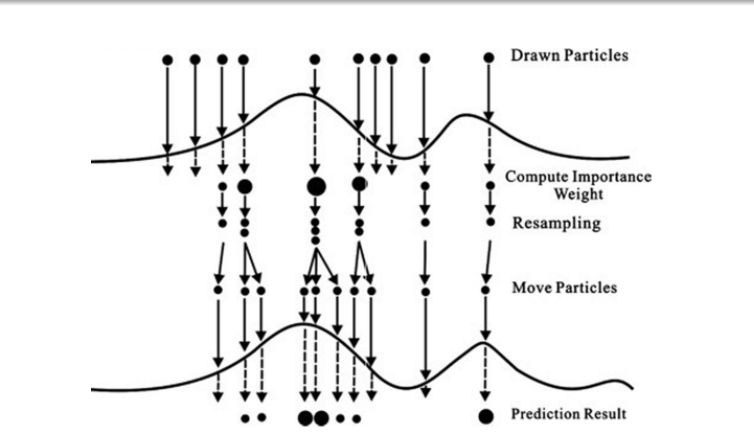

Для оценки параметров А фильтр создает множество гипотез (частиц) о текущем значении этих параметров. В начальный момент времени эти гипотезы абсолютно случайны, но на каждой итерации цикла фильтрации фильтр будет убирать гипотезы, которые не пройдет проверку достоверности, основанную на измерениях параметров Б.

Таким образом из множества гипотез в конце концов останутся только те, которые наиболее близки к истинному значению параметров А.

Основной параметр каждой частицы — её вес. Вес частицы определяет вероятность того, что координаты этой частицы совпадают с координатами робота. При этом, не зависимо от наличия априорной информации, вес всех частиц в начальный момент времени должен быть одинаковым и равным 1/N.


Отсев (Resampling)

Отсев нужен для того, чтобы отсеять частицы с низким весом, потому что они, по сути, являются мертвым грузом. Вес отсеиваемых частиц мал, а это означает, что вероятность расположения робота рядом с этими частицами пренебрежительно мала.

Суть отсева (Resampling) в том, чтобы из массива N частиц составить новый массив из N частиц, в который войдут только частицы с наибольшим весом. Если быть точнее, то каждая частица из первого массива переходит во второй (переживает отсев) с вероятностью равной её весу.

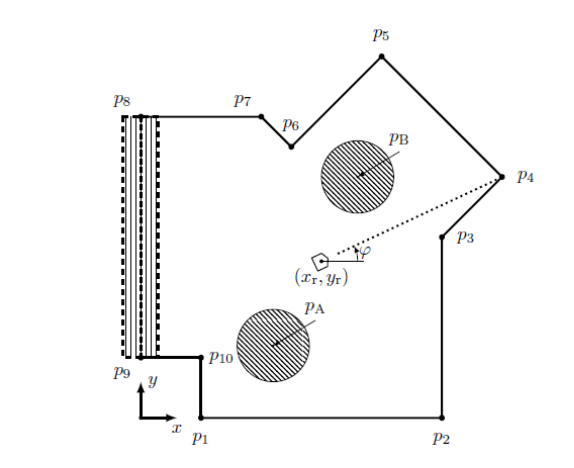

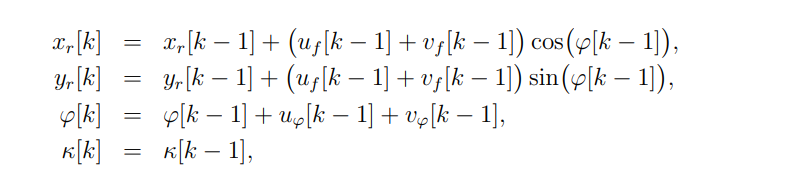

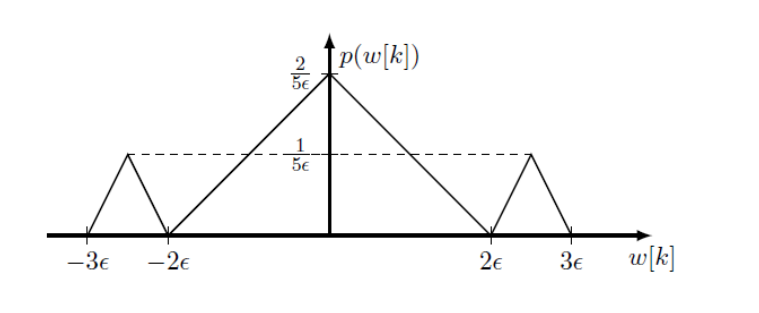

In [ ]:
# @title Импорты

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
from scipy.stats import triang
import random

from google.colab import files
import pandas as pd

In [ ]:
# @title Генерация параметров в момент k = 0

def sample_from_circle(cx, cy, r):
    R = np.sqrt(np.random.uniform(0, 1)) * r
    theta = np.random.uniform(0, 2*np.pi)
    x = cx + R * np.cos(theta)
    y = cy + R * np.sin(theta)
    return x, y


def generate_start_position_params(l):
    u = np.random.uniform(0, 1)

    if u <= 0.5:
        x0, y0 = sample_from_circle(1.1, 0.6, d) # pA
    else:
        x0, y0 = sample_from_circle(1.8, 2.0, d) # pB

    phi0 = np.random.uniform(-np.pi / 4, np.pi / 4)
    k0 = np.random.uniform(-l, l)

    return [x0, y0, phi0, k0]


In [ ]:
# @title Константы задачи

# kappa = 0    # параметр X для левых границ поля
d = 0.2
ell = 0.2
e = 0.01
sample_size_w_k = 500  # это для неймана просто чтобы показать выборку
N = 5000

sigma_f = 0.01
sigma_phi = 0.05

In [ ]:
# @title Инициализация поля и график для конкретной kappa

class Field():
    def __init__(self, k, d):
        self.k = k
        self.d = d
        self.landmarks= [
            (0.5, 0.0),   # p1
            (2.5, 0.0),   # p2
            (2.5, 1.5),   # p3
            (3.0, 2.0),   # p4
            (2.0, 3.0),   # p5
            (1.25, 2.25), # p6
            (1.0, 2.5),   # p7
            (self.k, 2.5),     # p8
            (self.k, 0.5),     # p9
            (0.5, 0.5),   # p10
            (1.1, 0.6),   # pA
            (1.8, 2.0)    # pB
        ]
        self.vertices = self.landmarks[:-2]
        self.start_area_points = self.landmarks[-2:]
        self.start_point_A = self.start_area_points[0]
        self.start_point_B = self.start_area_points[1]
        self.segments = self._create_segments()

    def _create_segments(self):
        segments = []
        for i in range(len(self.vertices) - 1):
            segments.append((self.vertices[i], self.vertices[i + 1]))
        segments.append((self.vertices[-1], self.vertices[0]))

        return segments


    def visualize(self, show_circles=True):
        x_verts, y_verts = zip(*self.vertices)
        order = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

        closed_x = [x_verts[i] for i in order] + [x_verts[order[0]]]
        closed_y = [y_verts[i] for i in order] + [y_verts[order[0]]]

        plt.figure(figsize=(10, 8))
        plt.plot(closed_x, closed_y, 'b-', linewidth=2, label='Field boundary')
        plt.plot(x_verts, y_verts, 'bo', markersize=6)

        for i, (x, y) in enumerate(self.vertices):
            plt.text(x, y, f'  p{i+1}', fontsize=9, verticalalignment='bottom')

        x_start, y_start = zip(*self.start_area_points)
        plt.plot(x_start, y_start, 'ro', markersize=8, label='Start area points')
        plt.text(x_start[0], y_start[0], '  pA', fontsize=9, color='red', fontweight='bold')
        plt.text(x_start[1], y_start[1], '  pB', fontsize=9, color='red', fontweight='bold')

        if show_circles:
            radius = self.d
            circle_A = patches.Circle(self.start_area_points[0], radius,
                                      facecolor='gray', edgecolor='black',
                                      alpha=0.5, hatch='///',
                                      label=f'Circles (d={self.d})')
            plt.gca().add_patch(circle_A)

            circle_B = patches.Circle(self.start_area_points[1], radius,
                                      facecolor='gray', edgecolor='black',
                                      alpha=0.5, hatch='///')
            plt.gca().add_patch(circle_B)

        plt.xlabel('X')
        plt.ylabel('Y')
        plt.title(f'Field Visualization (k={k}, d={self.d})')
        plt.axis('equal')
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.tight_layout()
        plt.show()

x, y, phi, k = generate_start_position_params(ell)

f = Field(k=k, d=d)
# f.visualize()

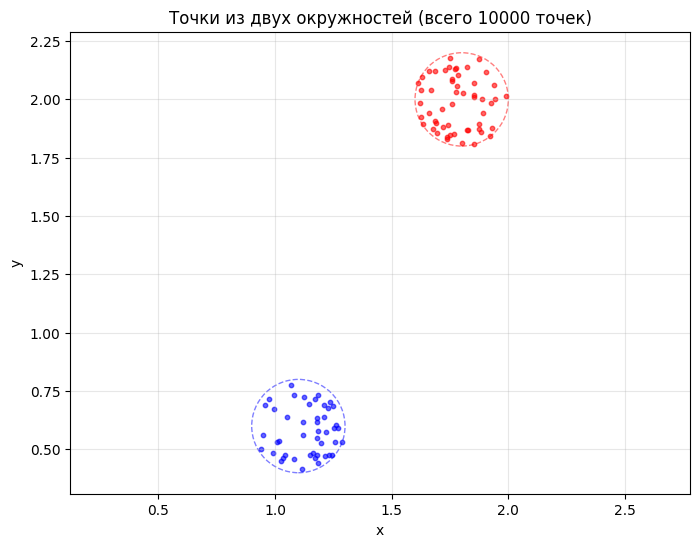

In [ ]:
# @title Визуализация генерации стартовых точек робота


# Формально это можно интерпретировать как смесь двух равномерных распределений с равными весами.

# Массивы для хранения результатов
x_points = []
y_points = []
colors = []
phi0_list = []
k0_list = []

n_for_vizualization = 100

# Генерация N точек в цикле
for _ in range(n_for_vizualization):
    # Генерация u для каждой точки
    u = np.random.uniform(0, 1)

    # Выбираем окружность
    if u <= 0.5:
        x, y = sample_from_circle(1.1, 0.6, d)  # окружность A
        colors.append('blue')
    else:
        x, y = sample_from_circle(1.8, 2.0, d)  # окружность B
        colors.append('red')

    phi = np.random.uniform(-np.pi / 4, np.pi / 4)
    k = np.random.uniform(-ell, ell)

    x_points.append(x)
    y_points.append(y)
    phi0_list.append(phi)
    k0_list.append(k)

x_points = np.array(x_points)
y_points = np.array(y_points)
phi0_list = np.array(phi0_list)
k0_list = np.array(k0_list)
colors = np.array(colors)

plt.figure(figsize=(8, 6))

for i in range(n_for_vizualization):
    plt.scatter(x_points[i], y_points[i], s=10, alpha=0.6, c=colors[i])

circle_a = plt.Circle((1.1, 0.6), d, fill=False, linestyle='--', alpha=0.5, color='blue')
circle_b = plt.Circle((1.8, 2.0), d, fill=False, linestyle='--', alpha=0.5, color='red')
plt.gca().add_patch(circle_a)
plt.gca().add_patch(circle_b)

plt.xlabel('x')
plt.ylabel('y')
plt.title(f'Точки из двух окружностей (всего {N} точек)')
plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# @title Уравнение динамики

def q(x_k, phi_k, U_f_k, V_f_k):
    x_k_next = x_k + (U_f_k + V_f_k) * np.cos(phi_k)
    return x_k_next

def h(y_k, phi_k, U_f_k, V_f_k):
    y_k_next = y_k + (U_f_k + V_f_k) * np.sin(phi_k)
    return y_k_next

def g(phi_k, U_phi_k, V_phi_k):
    phi_k_next = phi_k + (U_phi_k + V_phi_k)
    return phi_k_next

def l(k):
    return k


def update_state(state, u_f, u_phi, v_f, v_phi):
    """state = [x, y, phi, k]"""
    x = state[0]
    y = state[1]
    phi = state[2]
    k = state[3]
    return [
        q(x, phi, u_f, v_f),
        h(y, phi, u_f, v_f),
        g(phi, u_phi, v_phi),
        l(k)
    ]

In [ ]:
# @title Плотность распредления вероятностей аддитивного шума

# Плотность шума это кусочная функция, каждый промежуток это треугольная плотность
# [-3e, -2e), [-2e, 2e] и (2e, 3e]

def W_pdf(w_k, e=0.01):

    h_side_triangle = 1/(5*e)
    h_center_triangle = 2/(5*e)

    side_triangle_width = 0.5*e
    center_triangle_width = 4*e

    if abs(w_k) > 3*e:
        return 0.0

    if -3*e <= w_k < -2*e:
        if w_k <= -2.5*e:
            return ((w_k + 3*e) / side_triangle_width) * h_side_triangle
        else:
            return ((-w_k - 2*e) / side_triangle_width) * h_side_triangle

    if -2*e <= w_k <= 2*e:
        return (1 - abs(w_k)/(center_triangle_width / 2)) * h_center_triangle  # Вершина в 0

    if 2*e < w_k <= 3*e:
        if w_k <= 2.5*e:
            return ((w_k - 2*e) / side_triangle_width) * h_side_triangle
        else:
            return ((3*e - w_k) / side_triangle_width) * h_side_triangle

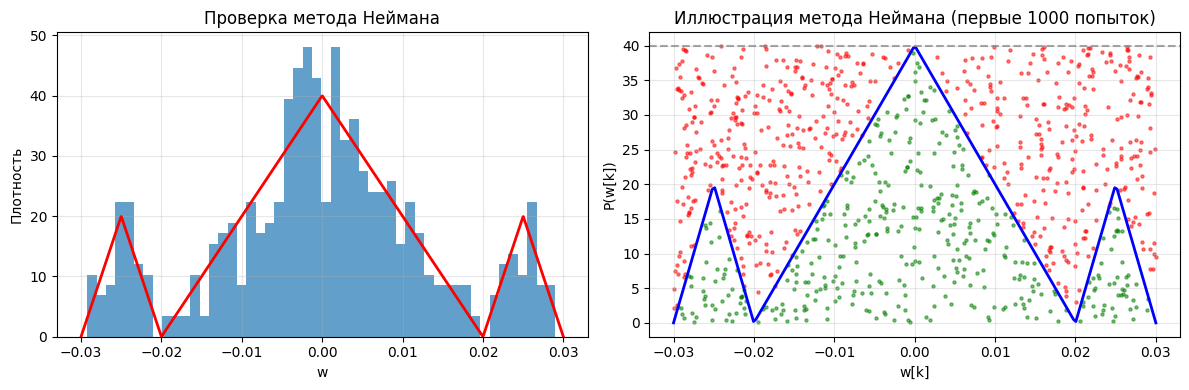

In [ ]:
# @title Генерация аддитивного шума методом Неймана + визуализация


def generate_w_neyman(sample_size=1000, e=0.01):
    y_max = 2/(5*e) # Максимум в точке w=0

    x_min, x_max = -3*e, 3*e # Область определения x: [-3e, 3e]
    x_range = x_max - x_min
    samples = []

    while len(samples) < sample_size:
        x = random.uniform(x_min, x_max)
        y = random.uniform(0, y_max)

        if y <= W_pdf(x, e):
            samples.append(x)

    return np.array(samples)


samples = generate_w_neyman(sample_size_w_k, e)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(samples, bins=50, density=True, alpha=0.7, label='Сгенерированная выборка')


w_vals = np.linspace(-3*e, 3*e, 1000)
pdf_vals = [W_pdf(w, e) for w in w_vals]
axes[0].plot(w_vals, pdf_vals, 'r-', linewidth=2, label='Теоретическая плотность')
axes[0].set_xlabel('w')
axes[0].set_ylabel('Плотность')
axes[0].set_title('Проверка метода Неймана')
axes[0].grid(True, alpha=0.3)


n_demo = 1000
x_demo = np.random.uniform(-3*e, 3*e, n_demo)
y_demo = np.random.uniform(0, 2/(5*e), n_demo)
accepted_mask = np.array([y_demo[i] <= W_pdf(x_demo[i], e) for i in range(n_demo)])

axes[1].scatter(x_demo[accepted_mask], y_demo[accepted_mask],
                c='green', s=5, alpha=0.5, label='Принятые')
axes[1].scatter(x_demo[~accepted_mask], y_demo[~accepted_mask],
                c='red', s=5, alpha=0.5, label='Отвергнутые')

w_fine = np.linspace(-3*e, 3*e, 200)
axes[1].plot(w_fine, [W_pdf(w, e) for w in w_fine], 'b-', linewidth=2, label='pdf(w)')
axes[1].axhline(y=2/(5*e), color='gray', linestyle='--', alpha=0.7, label=f'y_max = {2/(5*e):.0f}')
axes[1].set_xlabel('w[k]')
axes[1].set_ylabel('P(w[k])')
axes[1].set_title(f'Иллюстрация метода Неймана (первые {n_demo} попыток)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# @title Функция нахождения пересечения луча и отрезка

# псевдоскаляр
def cross(ux, uy, vx, vy):
    return ux * vy - uy * vx

def dot(ux, uy, vx, vy):
    return ux * vx + uy * vy

def ray_segment_intersection(ray_origin, ray_direction, segment_start, segment_end, eps=1e-9):
    Lx, Ly = ray_origin
    Dx, Dy = ray_direction
    Ax, Ay = segment_start
    Bx, By = segment_end

    Vx = Bx - Ax
    Vy = By - Ay
    Px = Ax - Lx
    Py = Ay - Ly

    denom = cross(Dx, Dy, Vx, Vy)

    # не параллельны
    if abs(denom) > eps:
        t = cross(Px, Py, Vx, Vy) / denom
        s = cross(Px, Py, Dx, Dy) / denom

        if t >= -eps and 0 - eps <= s <= 1 + eps:
            Qx = Lx + t * Dx
            Qy = Ly + t * Dy
            return (Qx, Qy)
        return None

    # Параллельны
    if abs(cross(Px, Py, Dx, Dy)) > eps:
        return None  # не лежат на одной прямой

    # Коллинеарны (или вырожденные случаи)
    dotDD = dot(Dx, Dy, Dx, Dy)

    if dotDD < eps:                     # луч вырожден в точку
        dotVV = dot(Vx, Vy, Vx, Vy)
        if dotVV < eps:                 # оба — точки
            return ray_origin if abs(Px) < eps and abs(Py) < eps else None
        # точка лежит на отрезке?
        s = dot(Px, Py, Vx, Vy) / dotVV
        return ray_origin if 0 - eps <= s <= 1 + eps else None

    # Обычный коллинеарный случай
    tA = dot(Ax - Lx, Ay - Ly, Dx, Dy) / dotDD
    tB = dot(Bx - Lx, By - Ly, Dx, Dy) / dotDD

    t_min = min(tA, tB)
    t_max = max(tA, tB)

    if t_max < -eps:
        return None

    t_start = max(t_min, 0.0)
    if t_start > t_max + eps:
        return None

    Qx = Lx + t_start * Dx
    Qy = Ly + t_start * Dy
    return (Qx, Qy)


In [ ]:
# @title Нахождение расстояния до границы поля - z[k]

def calculate_distance_to_border(x_r, y_r, phi, kappa):
    current_field = Field(k=kappa, d=f.d)
    intersections = []
    #ray_direction = (np.cos(np.radians(phi)), np.sin(np.radians(phi)))
    ray_direction = (np.cos(phi), np.sin(phi))

    for segment in current_field.segments:
        start = segment[0]
        end = segment[1]

        result = ray_segment_intersection((x_r, y_r), ray_direction, start, end)

        if result:
            x_c, y_c = result
            intersections.append((x_c, y_c))

    closest_intersection = None
    min_distance = float('inf')

    for intersection in intersections:
        dist = np.sqrt((intersection[0] - x_r)**2 + (intersection[1] - y_r)**2)
        if dist < min_distance:
            min_distance = dist
            closest_intersection = intersection

    if closest_intersection is None:
        return 1000.0

    z_k = np.sqrt((x_r - closest_intersection[0])**2 + (y_r - closest_intersection[1])**2)

    return z_k


In [ ]:
# @title Визуализация нахожденеия расстояние до границы многоугольника в заданном направлении

def visualize_field_ray(f, phi, ray_origin):

    x_verts, y_verts = zip(*f.vertices)
    order = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

    closed_x = [x_verts[i] for i in order] + [x_verts[order[0]]]
    closed_y = [y_verts[i] for i in order] + [y_verts[order[0]]]

    ray_direction = (np.cos(np.radians(phi)), np.sin(np.radians(phi)))

    intersections = []
    # i = 1
    for segment in f.segments:
        start = segment[0]
        end = segment[1]
        result = ray_segment_intersection(ray_origin, ray_direction, start, end)
        if result:
            intersections.append(result)
        #     print(f'p{i}-p{i+1} ----- {result}')
        # else:
        #     print(f'p{i}-p{i+1} ----- None')
        # i += 1

    closest_intersection = None
    min_distance = float('inf')

    for intersection in intersections:
        dist = np.sqrt((intersection[0] - ray_origin[0])**2 +
                       (intersection[1] - ray_origin[1])**2)
        if dist < min_distance:
            min_distance = dist
            closest_intersection = intersection

    plt.figure(figsize=(12, 10))
    plt.plot(closed_x, closed_y, 'b-', linewidth=2, label='Field boundary')
    plt.plot(x_verts, y_verts, 'bo', markersize=6)
    for i, (x, y) in enumerate(f.vertices):
        plt.text(x, y, f'  p{i+1}', fontsize=9, verticalalignment='bottom')

    plt.plot(ray_origin[0], ray_origin[1], 'g*', markersize=15,
             label=f'Ray origin ({ray_origin[0]}, {ray_origin[1]})',
             color='green', markeredgecolor='darkgreen', markeredgewidth=2)

    if closest_intersection:
        ray_end = closest_intersection
        direction_vector = np.array(ray_direction)
        extended_end = (ray_end[0] + direction_vector[0] * 0.5,
                        ray_end[1] + direction_vector[1] * 0.5)
    else:
        ray_length = 10.0
        ray_end = (ray_origin[0] + ray_direction[0] * ray_length,
                   ray_origin[1] + ray_direction[1] * ray_length)
        extended_end = ray_end

    plt.plot([ray_origin[0], ray_end[0]],
             [ray_origin[1], ray_end[1]],
             'g-', linewidth=2, label=f'Ray (φ={phi}°)', alpha=0.7)

    plt.annotate('', xy=ray_end, xytext=ray_origin,
                 arrowprops=dict(arrowstyle='->', color='green', lw=2, alpha=0.7))

    if intersections:
        intersections_x, intersections_y = zip(*intersections)
        plt.plot(intersections_x, intersections_y, 'rX', markersize=10,
                 label=f'Intersections ({len(intersections)})',
                 color='red', markeredgewidth=2)

        if closest_intersection:
            plt.plot(closest_intersection[0], closest_intersection[1],
                    'y*', markersize=15, label='Closest intersection',
                    color='gold', markeredgecolor='darkorange', markeredgewidth=2)

    angle_rad = np.radians(phi)
    text_x = ray_origin[0] + ray_direction[0] * 1.5
    text_y = ray_origin[1] + ray_direction[1] * 1.5
    plt.text(text_x, text_y, f'φ={phi}°', fontsize=10, color='green',
             bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

    if closest_intersection:
        plt.text(0.02, 0.98, f'Distance to border: {min_distance:.4f}',
                 transform=plt.gca().transAxes, fontsize=10,
                 verticalalignment='top', bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8))

    plt.xlabel('X', fontsize=12)
    plt.ylabel('Y', fontsize=12)
    plt.axis('equal')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

    return {
        'closest_intersection': closest_intersection,
        'min_distance': min_distance,
        'all_intersections': intersections
    }


visualize_field_ray(f, phi=155, ray_origin=(1.5, 1.0))

In [ ]:
# @title Подгрузка и обработка данных

uploaded = files.upload()

for filename in uploaded.keys():
    df = pd.read_csv(filename)
    print(df.head())

print(len(df))  # 500

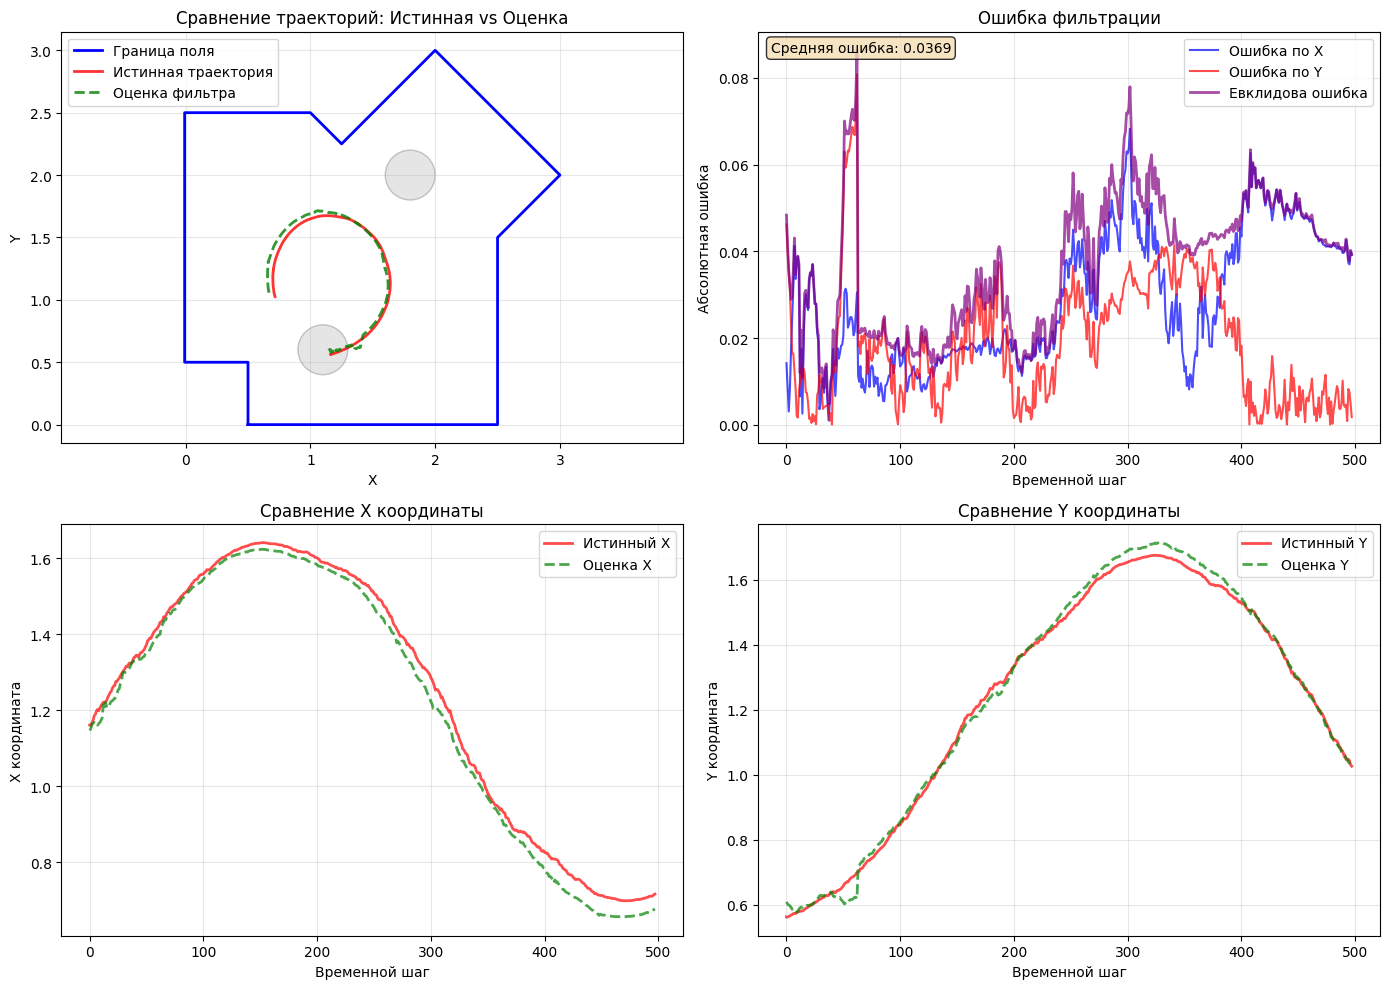

In [ ]:
# @title Основной цикл фильтра частиц сразу с графиками


# Частицы — гипотезы о состоянии   (x_r, y_r, phi, k), Веса  w[i] — насколько хорошо частица объясняет наблюдение z[k]

particles = []
weights = np.ones(N) / N
x_estimates = []
y_estimates = []

for i in range(N):
    x0, y0, phi0, k0 = generate_start_position_params(ell)
    particles.append([x0, y0, phi0, k0])

particles = np.array(particles)


# Основной цикл
for k in range(len(df)):
    z_k = df['distSensor'][k]
    u_f_k = df['Uf'][k]
    u_phi_k = df['Uphi'][k]

    new_particles = []

    for i in range(N):
        x, y, phi, kappa = particles[i]

        V_f = np.random.uniform(-sigma_f / 2, sigma_f / 2)
        V_phi = np.random.uniform(-sigma_phi / 2, sigma_phi / 2)

        x_new, y_new, phi_new, kappa = update_state([x, y, phi, kappa], u_f_k, u_phi_k, V_f, V_phi)

        new_particles.append([x_new, y_new, phi_new, kappa])

    particles = np.array(new_particles)


    for i in range(N):
        x, y, phi, kappa = particles[i]

        z_pred = calculate_distance_to_border(x, y, phi, kappa)
        w_k = z_k - z_pred

        try:
            weights[i] = W_pdf(w_k, e)
        except:
            weights[i] = 1e-12

    if np.any(np.isnan(weights)) or np.sum(weights) == 0:
        weights = np.ones(N) / N
        continue

    weights = weights / np.sum(weights)

    # Оценка состояния
    x_est = np.sum(particles[:, 0] * weights)
    y_est = np.sum(particles[:, 1] * weights)

    x_estimates.append(x_est)
    y_estimates.append(y_est)

    # Ресемплинг
    indices = np.random.choice(range(N), size=N, p=weights)
    particles = particles[indices]
    weights = np.ones(N) / N




min_len = min(len(df), len(x_estimates)) # Приводим к одинаковой длине

# Берем только совпадающие шаги
true_x = df['X'].values[:min_len]
true_y = df['Y'].values[:min_len]
est_x = x_estimates[:min_len]
est_y = y_estimates[:min_len]

# === 1. Сравнение траекторий (САМЫЙ ВАЖНЫЙ ГРАФИК) ===
plt.figure(figsize=(14, 10))

# Подграфик 1: Сравнение траекторий на поле
plt.subplot(2, 2, 1)

# Отрисовка границ поля
x_verts, y_verts = zip(*f.vertices)
order = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
closed_x = [x_verts[i] for i in order] + [x_verts[order[0]]]
closed_y = [y_verts[i] for i in order] + [y_verts[order[0]]]

plt.plot(closed_x, closed_y, 'b-', linewidth=2, label='Граница поля')

# ИСТИННАЯ траектория
plt.plot(true_x, true_y, 'r-', linewidth=2,
         label='Истинная траектория', alpha=0.8)

# ОЦЕНЁННАЯ траектория
plt.plot(est_x, est_y, 'g--', linewidth=2,
         label='Оценка фильтра', alpha=0.8)

# Стартовые области
radius = d
circle_A = patches.Circle(f.start_point_A, radius,
                          facecolor='gray', edgecolor='black',
                          alpha=0.2)
circle_B = patches.Circle(f.start_point_B, radius,
                          facecolor='gray', edgecolor='black',
                          alpha=0.2)
plt.gca().add_patch(circle_A)
plt.gca().add_patch(circle_B)

plt.xlabel('X')
plt.ylabel('Y')
plt.title('Сравнение траекторий: Истинная vs Оценка')
plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.legend(loc='best')

# === 2. Ошибка фильтрации ===
plt.subplot(2, 2, 2)

error_x = np.abs(true_x - est_x)
error_y = np.abs(true_y - est_y)
error_euclidean = np.sqrt(error_x**2 + error_y**2)

plt.plot(error_x, label='Ошибка по X', color='blue', alpha=0.7)
plt.plot(error_y, label='Ошибка по Y', color='red', alpha=0.7)
plt.plot(error_euclidean, label='Евклидова ошибка', color='purple', alpha=0.7, linewidth=2)
plt.xlabel('Временной шаг')
plt.ylabel('Абсолютная ошибка')
plt.title('Ошибка фильтрации')
plt.grid(True, alpha=0.3)
plt.legend()

# Средняя ошибка
mean_error = np.mean(error_euclidean)
plt.text(0.02, 0.95, f'Средняя ошибка: {mean_error:.4f}',
         transform=plt.gca().transAxes, fontsize=10,
         bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8))

# === 3. Сравнение X координаты во времени ===
plt.subplot(2, 2, 3)

plt.plot(true_x, 'r-', label='Истинный X', linewidth=2, alpha=0.7)
plt.plot(est_x, 'g--', label='Оценка X', linewidth=2, alpha=0.7)
plt.xlabel('Временной шаг')
plt.ylabel('X координата')
plt.title('Сравнение X координаты')
plt.grid(True, alpha=0.3)
plt.legend()

# === 4. Сравнение Y координаты во времени ===
plt.subplot(2, 2, 4)

plt.plot(true_y, 'r-', label='Истинный Y', linewidth=2, alpha=0.7)
plt.plot(est_y, 'g--', label='Оценка Y', linewidth=2, alpha=0.7)
plt.xlabel('Временной шаг')
plt.ylabel('Y координата')
plt.title('Сравнение Y координаты')
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
# @title Основной цикл фильтра частиц


# Частицы — гипотезы о состоянии   (x_r, y_r, phi, k)
# Веса  w[i] — насколько хорошо частица объясняет наблюдение z[k]

particles = []
weights = np.ones(N) / N

for i in range(N):
    x0, y0, phi0, k0 = generate_start_position_params(ell)
    particles.append([x0, y0, phi0, k0])

particles = np.array(particles)

# Для хранения оценок
x_estimates = []
y_estimates = []

particles_history = []


# Основной цикл
for k in range(len(df)):
    z_k = df['distSensor'][k]
    u_f_k = df['Uf'][k]
    u_phi_k = df['Uphi'][k]

    new_particles = []

    # Прогноз
    for i in range(N):
        x, y, phi, kappa = particles[i]

        V_f = np.random.uniform(-sigma_f / 2, sigma_f / 2)
        V_phi = np.random.uniform(-sigma_phi / 2, sigma_phi / 2)

        x_new, y_new, phi_new, kappa = update_state([x, y, phi, kappa], u_f_k, u_phi_k, V_f, V_phi)

        new_particles.append([x_new, y_new, phi_new, kappa])

    particles = np.array(new_particles)

    # Обновление весов
    for i in range(N):
        x, y, phi, kappa = particles[i]

        z_pred = calculate_distance_to_border(x, y, phi)
        w_k = z_k - z_pred

        try:
            weights[i] = W_pdf(w_k, e)
        except:
            weights[i] = 1e-12

    # Проверка весов
    if np.any(np.isnan(weights)) or np.sum(weights) == 0:
        weights = np.ones(N) / N
        continue
    # if np.any(np.isnan(weights)):
    #     weights = np.ones(N) / N
    #     continue

    # Нормализация
    weights = weights / np.sum(weights)

    # Оценка состояния
    x_est = np.sum(particles[:, 0] * weights)
    y_est = np.sum(particles[:, 1] * weights)

    x_estimates.append(x_est)
    y_estimates.append(y_est)

    # === 6. Ресемплинг ===
    indices = np.random.choice(range(N), size=N, p=weights)
    particles = particles[indices]

    # после ресемплинга веса равномерные
    weights = np.ones(N) / N

    particles_history.append(particles.copy())

In [ ]:
# @title Улучшенная визуализация


min_len = min(len(df), len(x_estimates)) # Приводим к одинаковой длине

# Берем только совпадающие шаги
true_x = df['X'].values[:min_len]
true_y = df['Y'].values[:min_len]
est_x = x_estimates[:min_len]
est_y = y_estimates[:min_len]

# === 1. Сравнение траекторий (САМЫЙ ВАЖНЫЙ ГРАФИК) ===
plt.figure(figsize=(14, 10))

# Подграфик 1: Сравнение траекторий на поле
plt.subplot(2, 2, 1)

# Отрисовка границ поля
x_verts, y_verts = zip(*f.vertices)
order = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
closed_x = [x_verts[i] for i in order] + [x_verts[order[0]]]
closed_y = [y_verts[i] for i in order] + [y_verts[order[0]]]

plt.plot(closed_x, closed_y, 'b-', linewidth=2, label='Граница поля')

# ИСТИННАЯ траектория
plt.plot(true_x, true_y, 'r-', linewidth=2,
         label='Истинная траектория', alpha=0.8)

# ОЦЕНЁННАЯ траектория
plt.plot(est_x, est_y, 'g--', linewidth=2,
         label='Оценка фильтра', alpha=0.8)

# Стартовые области
radius = d
circle_A = patches.Circle(f.start_point_A, radius,
                          facecolor='gray', edgecolor='black',
                          alpha=0.2)
circle_B = patches.Circle(f.start_point_B, radius,
                          facecolor='gray', edgecolor='black',
                          alpha=0.2)
plt.gca().add_patch(circle_A)
plt.gca().add_patch(circle_B)

plt.xlabel('X')
plt.ylabel('Y')
plt.title('Сравнение траекторий: Истинная vs Оценка')
plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.legend(loc='best')

# === 2. Ошибка фильтрации ===
plt.subplot(2, 2, 2)

error_x = np.abs(true_x - est_x)
error_y = np.abs(true_y - est_y)
error_euclidean = np.sqrt(error_x**2 + error_y**2)

plt.plot(error_x, label='Ошибка по X', color='blue', alpha=0.7)
plt.plot(error_y, label='Ошибка по Y', color='red', alpha=0.7)
plt.plot(error_euclidean, label='Евклидова ошибка', color='purple', alpha=0.7, linewidth=2)
plt.xlabel('Временной шаг')
plt.ylabel('Абсолютная ошибка')
plt.title('Ошибка фильтрации')
plt.grid(True, alpha=0.3)
plt.legend()

# Средняя ошибка
mean_error = np.mean(error_euclidean)
plt.text(0.02, 0.95, f'Средняя ошибка: {mean_error:.4f}',
         transform=plt.gca().transAxes, fontsize=10,
         bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8))

# === 3. Сравнение X координаты во времени ===
plt.subplot(2, 2, 3)

plt.plot(true_x, 'r-', label='Истинный X', linewidth=2, alpha=0.7)
plt.plot(est_x, 'g--', label='Оценка X', linewidth=2, alpha=0.7)
plt.xlabel('Временной шаг')
plt.ylabel('X координата')
plt.title('Сравнение X координаты')
plt.grid(True, alpha=0.3)
plt.legend()

# === 4. Сравнение Y координаты во времени ===
plt.subplot(2, 2, 4)

plt.plot(true_y, 'r-', label='Истинный Y', linewidth=2, alpha=0.7)
plt.plot(est_y, 'g--', label='Оценка Y', linewidth=2, alpha=0.7)
plt.xlabel('Временной шаг')
plt.ylabel('Y координата')
plt.title('Сравнение Y координаты')
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()